In [1]:
# Main Logistic Regression implementation
import numpy as np


class LogisticRegression:
    def __init__(
        self,
        learning_rate=0.01,
        n_iterations=1000,
        batch_size=None,
        l2_lambda=0.0,
        early_stopping=False,
        tol=1e-6,
        scale=True,
        threshold=0.5,
        verbose=False,
        random_state=42,
    ):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.batch_size = batch_size
        self.l2_lambda = l2_lambda
        self.early_stopping = early_stopping
        self.tol = tol
        self.scale = scale
        self.threshold = threshold
        self.verbose = verbose
        self.random_state = random_state

        self.weights = None
        self.bias = None
        self.cost_history = []
        self.X_mean = None
        self.X_std = None

    # -----------------------------
    # Utilities
    # -----------------------------
    def _validate_inputs(self, X, y=None):
        X = np.array(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        if y is not None:
            y = np.array(y, dtype=float)
            if len(X) != len(y):
                raise ValueError("X and y must have same length")
            return X, y

        return X

    def _scale_features(self, X, training=False):
        if not self.scale:
            return X

        if training:
            self.X_mean = X.mean(axis=0)
            self.X_std = X.std(axis=0)
            self.X_std[self.X_std == 0] = 1

        return (X - self.X_mean) / self.X_std

    # -----------------------------
    # Core math
    # -----------------------------
    def _sigmoid(self, z):
        # numerical stability
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _compute_cost(self, y_true, y_pred_prob):
        n = len(y_true)
        eps = 1e-15
        y_pred_prob = np.clip(y_pred_prob, eps, 1 - eps)

        loss = -(1 / n) * np.sum(
            y_true * np.log(y_pred_prob) +
            (1 - y_true) * np.log(1 - y_pred_prob)
        )

        if self.l2_lambda > 0:
            loss += (self.l2_lambda / (2 * n)) * np.sum(self.weights ** 2)

        return loss

    # -----------------------------
    # Training
    # -----------------------------
    def fit(self, X, y):
        np.random.seed(self.random_state)

        X, y = self._validate_inputs(X, y)
        X = self._scale_features(X, training=True)

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.cost_history = []

        batch_size = self.batch_size or n_samples
        prev_cost = float("inf")

        for epoch in range(self.n_iterations):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for start in range(0, n_samples, batch_size):
                end = start + batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                linear = np.dot(X_batch, self.weights) + self.bias
                probs = self._sigmoid(linear)

                error = probs - y_batch
                m = len(y_batch)

                dw = (1 / m) * np.dot(X_batch.T, error)
                db = (1 / m) * np.sum(error)

                if self.l2_lambda > 0:
                    dw += (self.l2_lambda / m) * self.weights

                self.weights -= self.lr * dw
                self.bias -= self.lr * db

            # full cost
            full_probs = self._sigmoid(np.dot(X, self.weights) + self.bias)
            cost = self._compute_cost(y, full_probs)
            self.cost_history.append(cost)

            if self.verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {cost:.6f}")

            if self.early_stopping and abs(prev_cost - cost) < self.tol:
                if self.verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

            prev_cost = cost

        return self

    # -----------------------------
    # Prediction
    # -----------------------------
    def predict_proba(self, X):
        if self.weights is None:
            raise ValueError("Model is not trained yet.")

        X = self._validate_inputs(X)
        X = self._scale_features(X, training=False)

        linear = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear)

    def predict(self, X):
        probs = self.predict_proba(X)
        return (probs >= self.threshold).astype(int)

    # -----------------------------
    # Metrics
    # -----------------------------
    def accuracy(self, y_true, y_pred):
        return np.mean(y_true == y_pred)

    def precision(self, y_true, y_pred):
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        return tp / (tp + fp + 1e-15)

    def recall(self, y_true, y_pred):
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        return tp / (tp + fn + 1e-15)

    def f1_score(self, y_true, y_pred):
        p = self.precision(y_true, y_pred)
        r = self.recall(y_true, y_pred)
        return 2 * p * r / (p + r + 1e-15)


Epoch 0, Loss: 0.678388
Epoch 100, Loss: 0.342708
Epoch 200, Loss: 0.315196
Epoch 300, Loss: 0.307921
Epoch 400, Loss: 0.305283
Epoch 500, Loss: 0.304180
Epoch 600, Loss: 0.303681
Epoch 700, Loss: 0.303444
Epoch 800, Loss: 0.303328
Epoch 900, Loss: 0.303270
Accuracy: 0.86
Precision: 0.8627450980392157
Recall: 0.8627450980392157
F1 Score: 0.8627450980392152


Epoch 0, Loss: 0.678388
Epoch 100, Loss: 0.342708
Epoch 200, Loss: 0.315196
Epoch 300, Loss: 0.307921
Epoch 400, Loss: 0.305283
Epoch 500, Loss: 0.304180
Epoch 600, Loss: 0.303681
Epoch 700, Loss: 0.303444
Epoch 800, Loss: 0.303328
Epoch 900, Loss: 0.303270
Accuracy: 0.86
Precision: 0.8627450980392157
Recall: 0.8627450980392157
F1 Score: 0.8627450980392152


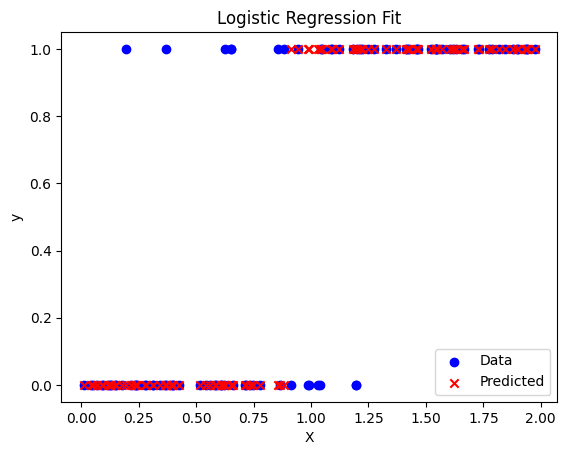

In [2]:
# Test the LogisticRegression implementation
import matplotlib.pyplot as plt

# Generate synthetic binary classification data
def make_data(n=100, random_state=42):
    np.random.seed(random_state)
    X = 2 * np.random.rand(n, 1)
    y = (4 + 3 * X[:, 0] + np.random.randn(n)) > 6.5
    return X, y.astype(int)

X, y = make_data()

# Initialize and fit the model
model = LogisticRegression(learning_rate=0.1, n_iterations=1000, verbose=True)
model.fit(X, y)
y_pred = model.predict(X)

# Print metrics
print("Accuracy:", model.accuracy(y, y_pred))
print("Precision:", model.precision(y, y_pred))
print("Recall:", model.recall(y, y_pred))
print("F1 Score:", model.f1_score(y, y_pred))

# Plot results
plt.scatter(X, y, color="blue", label="Data")
plt.scatter(X, y_pred, color="red", marker="x", label="Predicted")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Logistic Regression Fit")
plt.legend()
plt.show()
